# Chapter 7 - Exploratory Data Analysis

*This notebook contains all the sample code in Chapter 7.*


## Outline

- [Using Pandas](#Pandas)
- [The Seaborn library](#Seaborn)
- [Main plots](#Main_plots)
    - [Relational plots](#Relational_plots)
    - [Regression plots](#Regression_plots)
    - [Distribution plots](#Distribution_plots)
    - [Multi-plot grids](#Multi_plots)
    - [Categorical plots](#Categorical_plots)
    - [Matrix plots](#Matrix_plots)
    - [Multidimensional data plots](#Multidimensional_plots)

## Using Pandas <a id="Pandas"></a>


**Exploratory data analysis** (**EDA**) can be performed using the Pandas library:

In [1]:
import pandas as pd

file_name = './data/titanic.csv'
df = pd.read_csv(file_name)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Recall that the Pandas `shape` attribute returns a tuple containing the number of **rows** and **columns**:

In [2]:
df.shape

(891, 12)

Pandas also provides convenient methods for computing **summary statistics**:

In [3]:
df.iloc[:, [2, 9]].describe()

,Pclass,Fare
count,891.000000,891.000000
mean,2.308642,32.204208
std,0.836071,49.693429
min,1.000000,0.000000
25%,2.000000,7.910400
50%,3.000000,14.454200
75%,3.000000,31.000000
max,3.000000,512.329200


## The Seaborn library <a id="Seaborn"></a>

A more advanced tool for exploratory data analysis is **Seaborn**, imported as:

In [4]:
import seaborn as sns

Several example **datasets** are included within the library:

In [5]:
df1 = sns.load_dataset("iris")
df2 = sns.load_dataset("titanic")
df3 = sns.load_dataset("penguins")
df4 = sns.load_dataset("tips")

The names of available datasets can be retrieved using:

In [6]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


**Seaborn** provides five predefined themes that control the **overall appearance** of plots, which can be set as:

In [7]:
sns.set_style("whitegrid")

**Seaborn** allows customization of **color palettes**:

In [8]:
sns.set_palette("colorblind")

**Seaborn** returns DataFrame objects. Therefore, tehy are used as in Pandas:

In [9]:
df2.shape

(891, 15)

In [10]:
df2.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


We can also use Pandas to get some *summary* **statistics** for our data. The `describe` method excludes from count the `NaN` values. Try to give a look at the third and tenth columns in the Titanic dataset:

In [11]:
df2.iloc[:, [2, 9]].describe()

,sex,who
count,891,891
unique,2,3
top,male,man
freq,577,537


## Main plots <a id="Main_plots"></a>

Seaborn offers a rich collection of **statistical graphics**. The main types of plots are presented in the following.

### Relational plots <a id="Relational_plots"></a>

A **scatterplot** displays the relationship between two numerical variables by plotting individual data points:

<Axes: xlabel='age', ylabel='fare'>

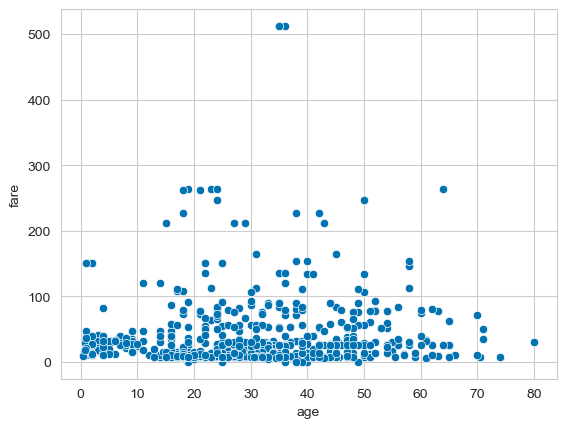

In [12]:
sns.scatterplot(x='age', y='fare', data=df2)

Many Seaborn functions support the `hue` parameter, which enables grouping of data points using different colors:

<Axes: xlabel='age', ylabel='fare'>

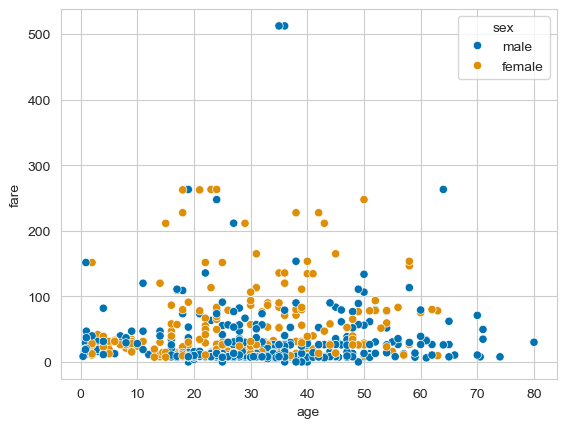

In [13]:
sns.scatterplot(x='age', y='fare', data=df2, hue='sex')

A **lineplot** connects data points with lines:

<Axes: xlabel='age', ylabel='fare'>

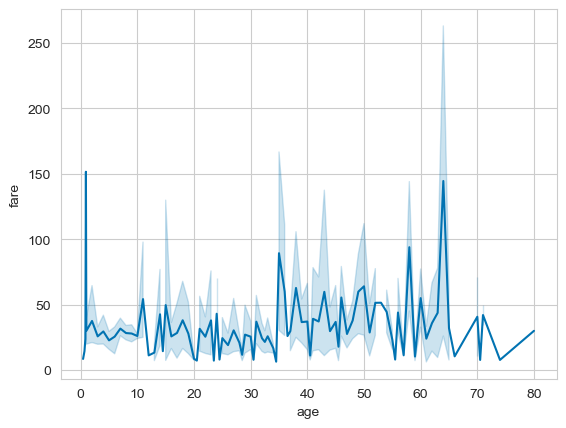

In [14]:
sns.lineplot(x='age', y='fare', data=df2)

<Axes: xlabel='age', ylabel='fare'>

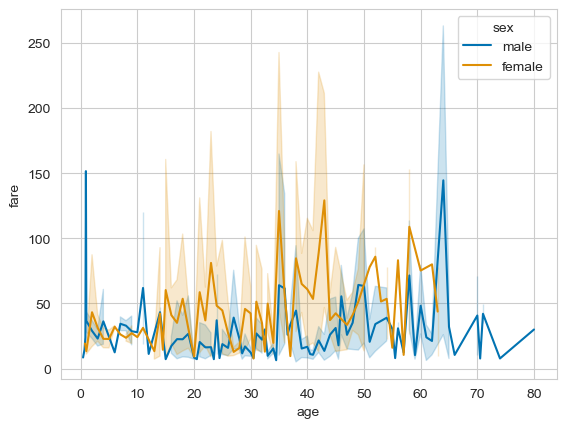

In [15]:
sns.lineplot(x='age', y='fare', data=df2, hue='sex')

The **relplot** function provides a more flexible, *figure-level* interface for relational plots:

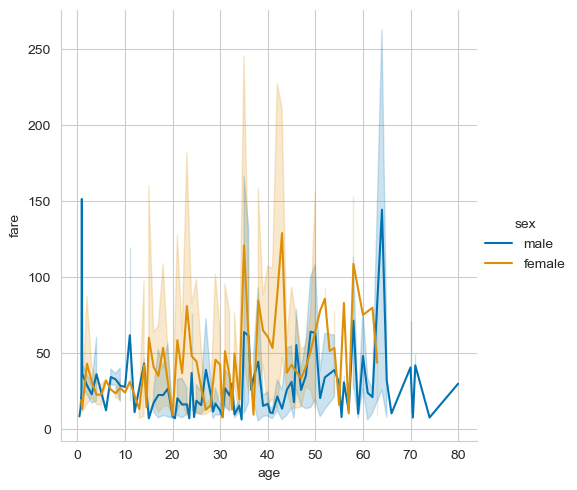

In [16]:
sns.relplot(x='age', y='fare', hue='sex', data=df2, kind='line')

### Regression plots <a id="Regression_plots"></a>

The **regplot** function displays both the *data points* and the *fitted linear regression* model:

<Axes: xlabel='total_bill', ylabel='tip'>

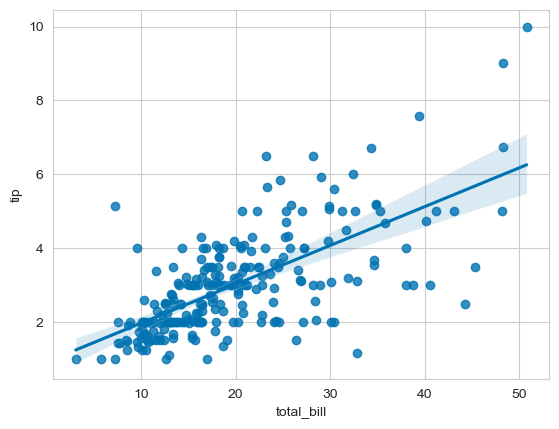

In [17]:
sns.regplot(x="total_bill", y="tip", data=df4)

The optional `logx` parameter fits a regression model to a logarithmic form:

<Axes: xlabel='total_bill', ylabel='tip'>

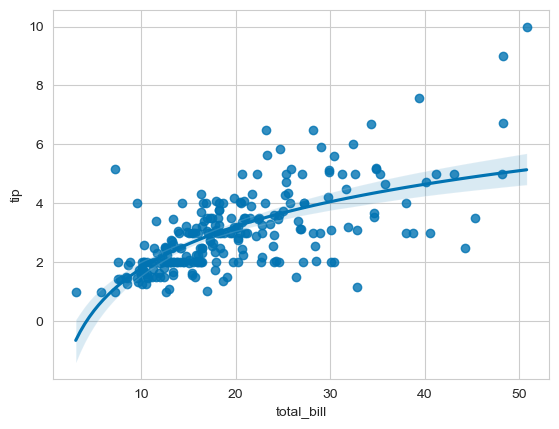

In [18]:
sns.regplot(x="total_bill", y="tip", data=df4, logx=True)

The **residplot** function computes a regression of $y$ on $x$ (linear by default) and displays the *residuals*:

<Axes: xlabel='total_bill', ylabel='tip'>

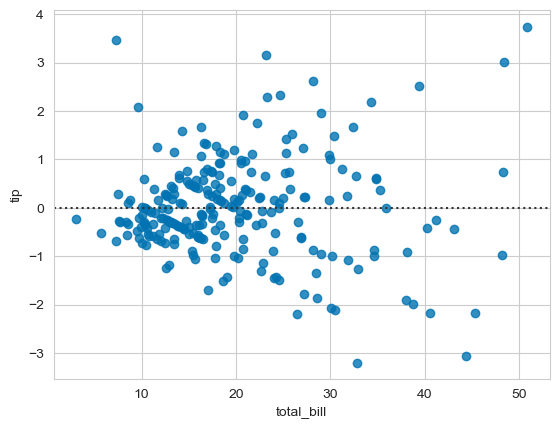

In [19]:
sns.residplot(x="total_bill", y="tip", data=df4)

The figure-level function **lmplot** supports the `hue` parameter:

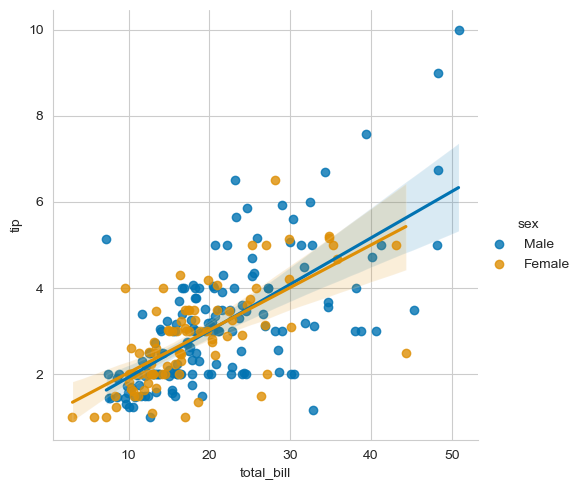

In [20]:
sns.lmplot(x="total_bill", y="tip", hue='sex', data=df4)

### Distribution plots <a id="Distribution_plots"></a>

A **histogram** provides a discrete approximation of the *probability density function* (**PDF**):

<Axes: xlabel='sepal_length', ylabel='Count'>

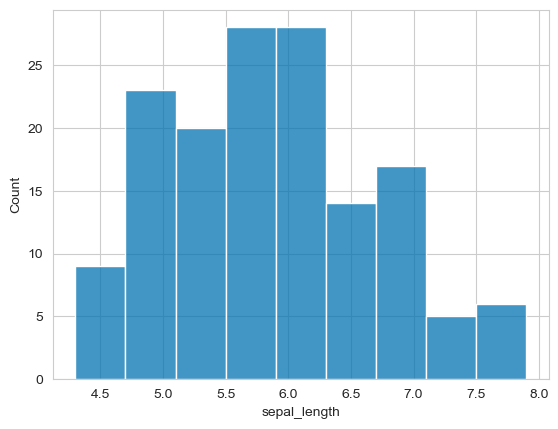

In [21]:
sns.histplot(data=df1, x='sepal_length')

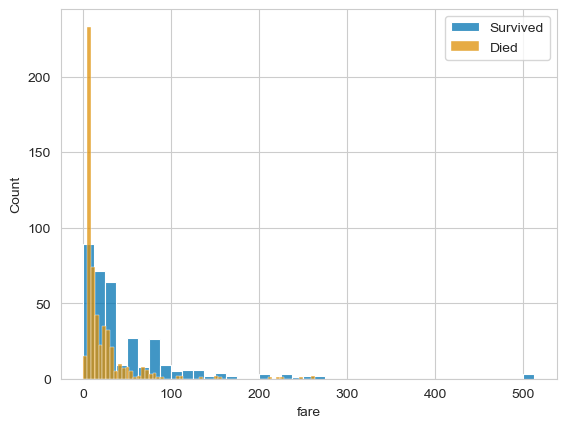

In [22]:
import matplotlib.pyplot as plt

sns.histplot(df2[df2['survived']==1].fare,label='Survived')
sns.histplot(df2[df2['survived']==0].fare,label='Died')
plt.legend()

<Axes: xlabel='tip', ylabel='Count'>

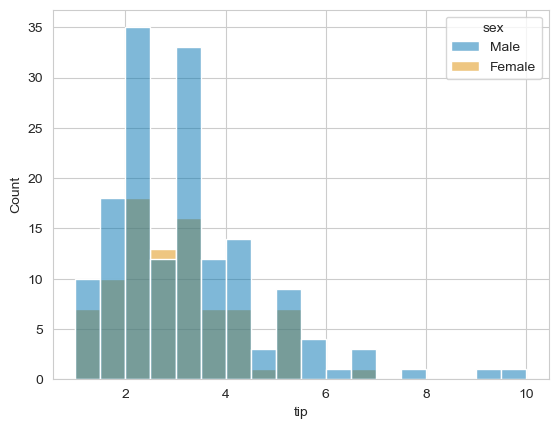

In [23]:
sns.histplot(data=df4, x="tip", hue='sex')

<Axes: xlabel='tip', ylabel='Count'>

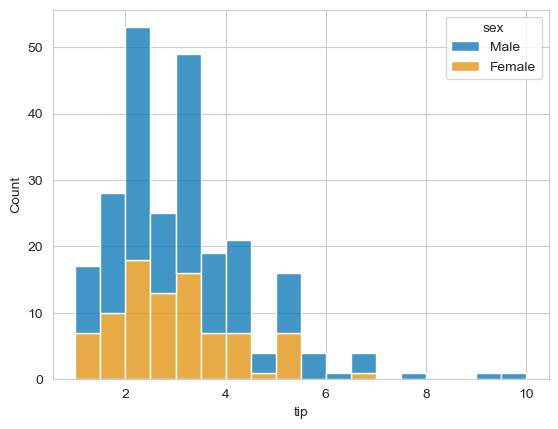

In [24]:
sns.histplot(data=df4, x="tip", hue='sex', multiple='stack')

A smoother estimation of the probability density function can be obtained by using the **Parzen Window** method:

<Axes: xlabel='total_bill', ylabel='Density'>

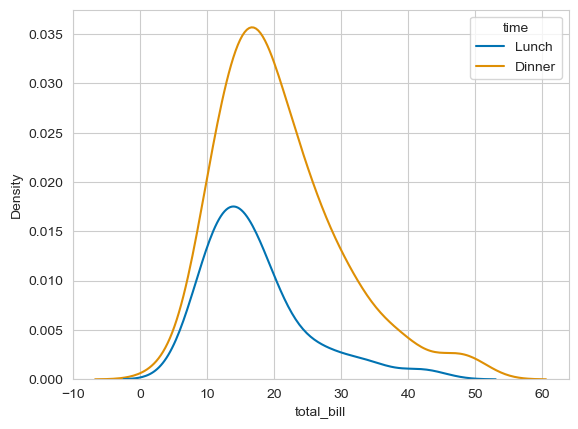

In [25]:
sns.kdeplot(data=df4, x="total_bill", hue="time")

<Axes: xlabel='total_bill', ylabel='Density'>

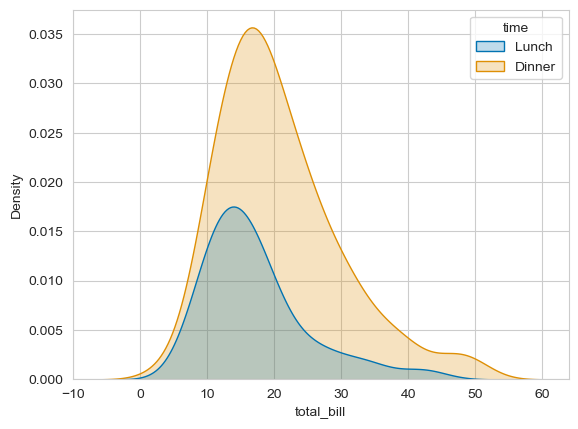

In [26]:
sns.kdeplot(data=df4, x="total_bill", hue="time", fill=True)

The **empirical cumulative distribution function** (**EDF**) can be visualized by:

<Axes: xlabel='bill_length_mm', ylabel='Proportion'>

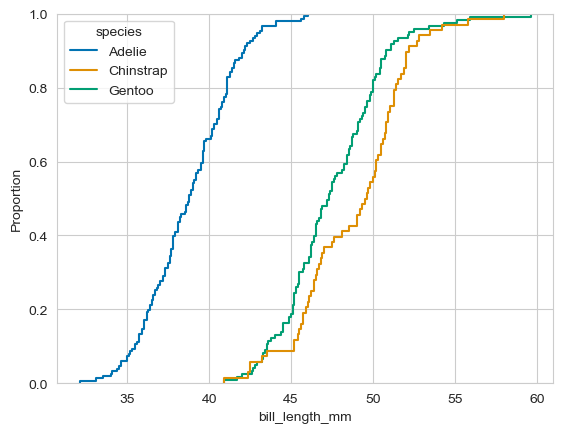

In [27]:
sns.ecdfplot(data=df3, x="bill_length_mm", hue="species")

The **rugplot** function adds small ticks along the $x$ and $y$ axes to indicate the position of individual observations:

<Axes: xlabel='total_bill', ylabel='tip'>

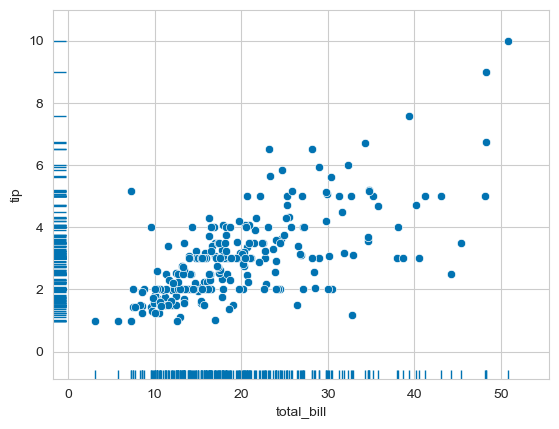

In [28]:
sns.scatterplot(data=df4, x="total_bill", y="tip")
sns.rugplot(data=df4, x="total_bill", y="tip")

The *figure-level* function **displot** provides a unified interface for distribution plots:

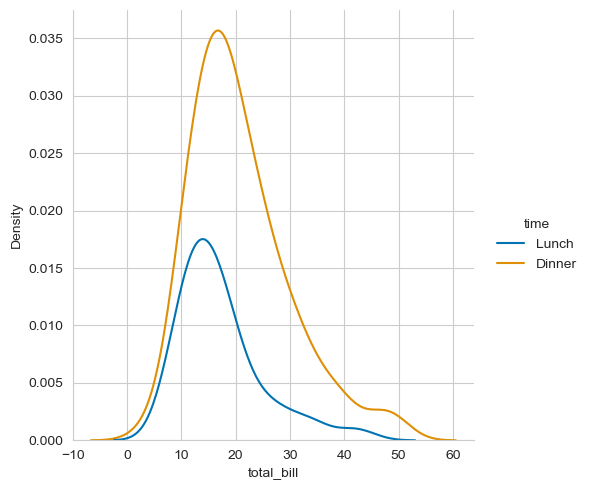

In [29]:
sns.displot(data=df4, x="total_bill", hue="time", kind='kde')

### Multi-plot grids <a id="Multi_plots"></a>

The `pairplot` function visualizes pairwise relationships between variables:

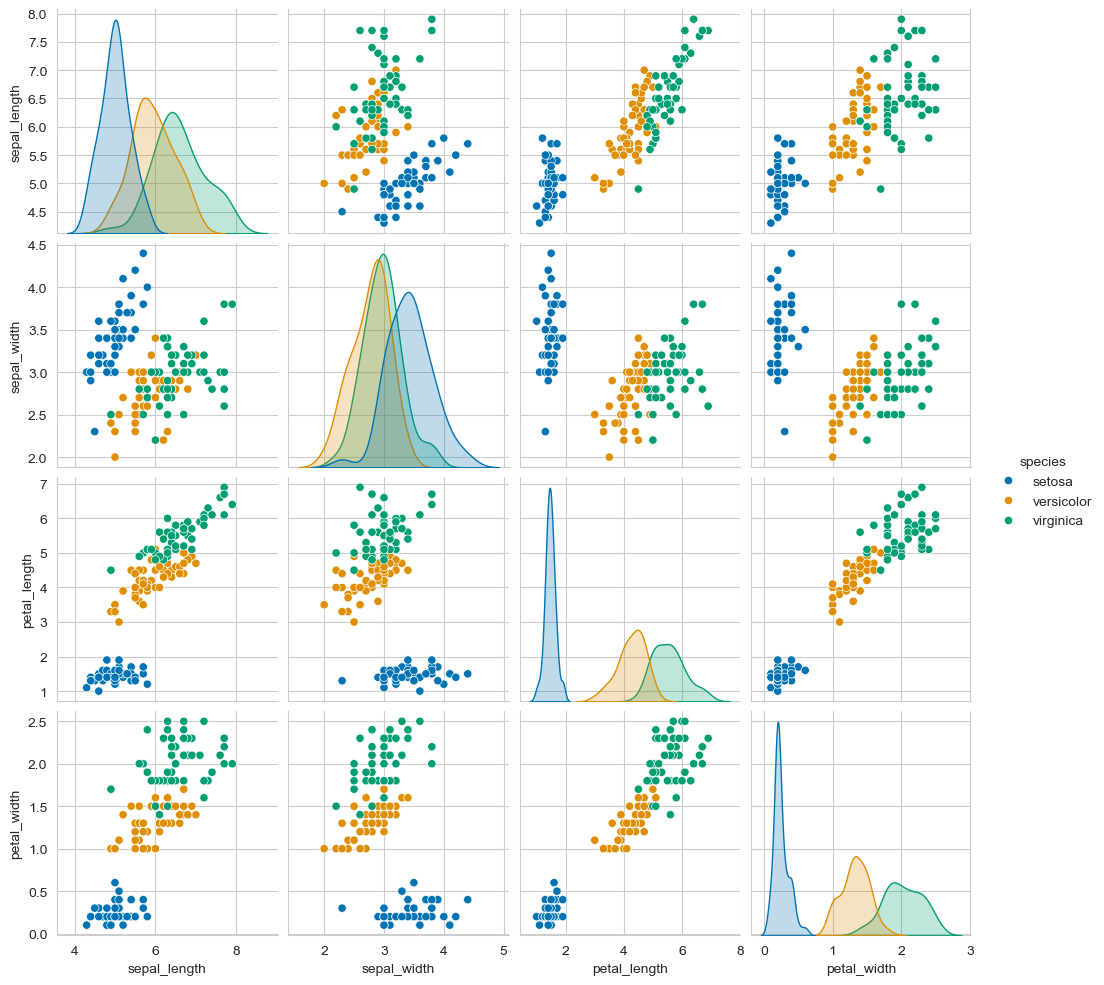

In [30]:
sns.pairplot(df1, hue="species")

The `jointplot` function shows the relationship between two variablesto along with their *marginal distributions*:

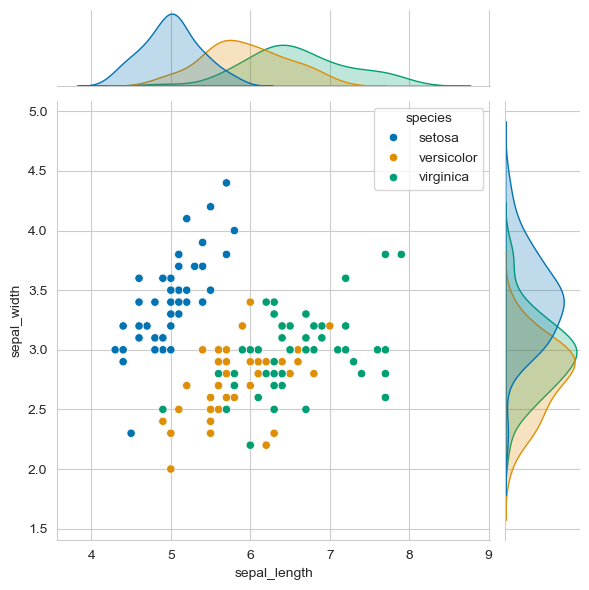

In [31]:
sns.jointplot(data=df1, x="sepal_length", y="sepal_width", hue="species")

A more general object is the **FacetGrid** class that provides a flexible way to create multi-panel plots:

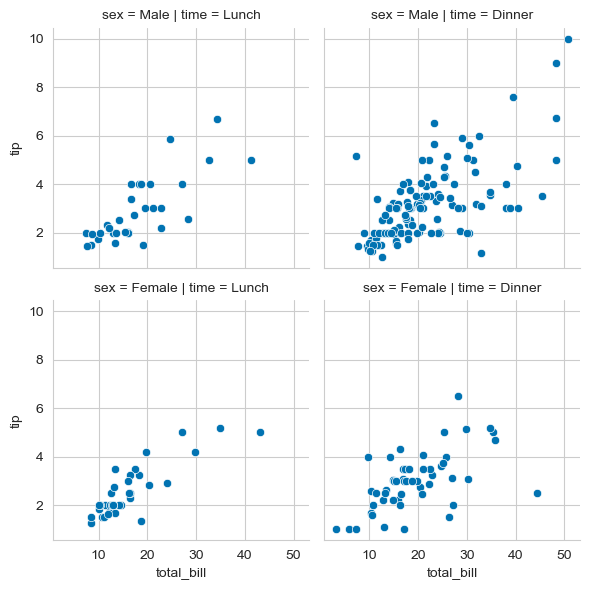

In [32]:
g = sns.FacetGrid(df4, col="time",  row="sex")
g.map(sns.scatterplot, "total_bill", "tip")

### Categorical plots <a id="Categorical_plots"></a>

A **countplot** displays the number of observations in each category using bars:

<Axes: xlabel='class', ylabel='count'>

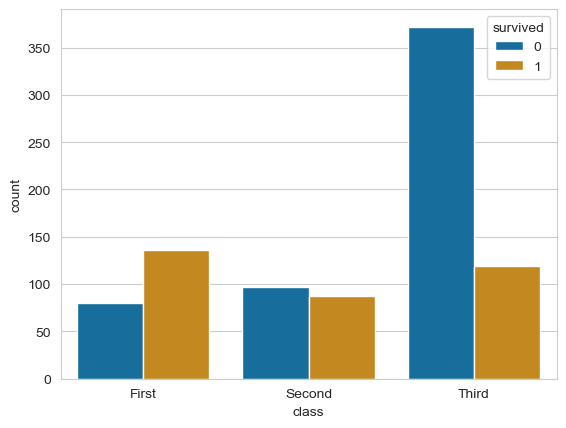

In [33]:
sns.countplot(data=df2, x="class", hue="survived")

A **barplot** shows aggregate statistics along with confidence intervals:

<Axes: xlabel='class', ylabel='fare'>

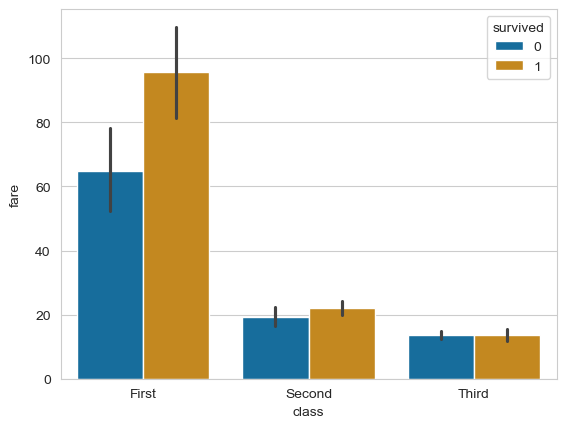

In [34]:
sns.barplot(data=df2, x="class", y="fare", hue="survived")

A **pointplot** provides a similar visualization using points and error bars:

<Axes: xlabel='island', ylabel='body_mass_g'>

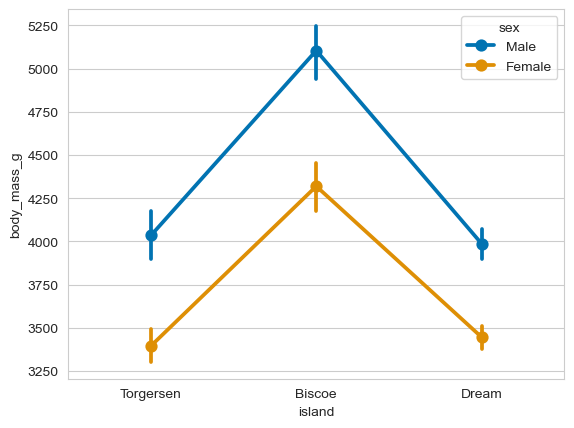

In [35]:
sns.pointplot(data=df3, x="island", y="body_mass_g", hue="sex")

A **boxplot** summarizes the distribution using quartiles and highlights outliers::

<Axes: >

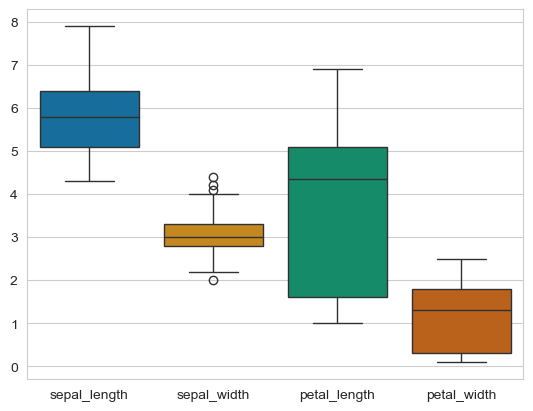

In [36]:
sns.boxplot(data=df1)

<Axes: xlabel='age'>

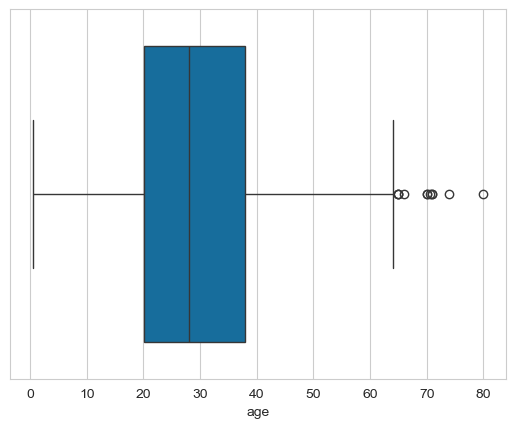

In [37]:
sns.boxplot(x=df2["age"])

We can also explicitly specify the $x$ and $y$-axis, or coloring the box according to another feature:

<Axes: xlabel='age', ylabel='pclass'>

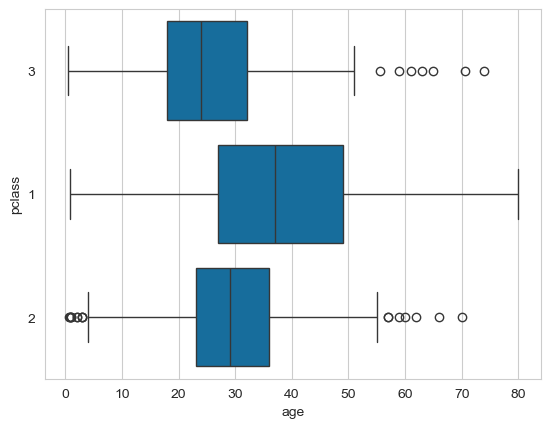

In [38]:
df2['pclass'] = df2.pclass.astype(str)
sns.boxplot(data=df2, x="age", y="pclass")

<Axes: xlabel='age', ylabel='pclass'>

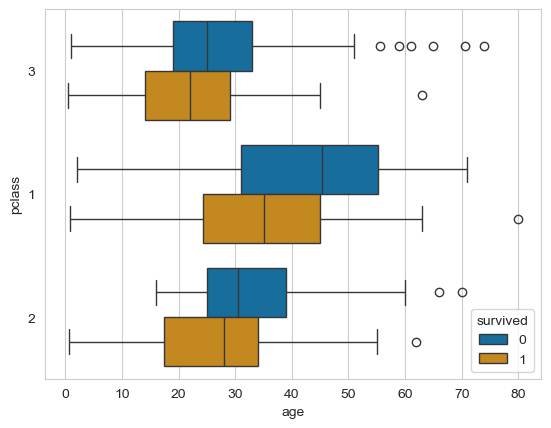

In [39]:
sns.boxplot(data=df2, x="age", y="pclass", hue="survived")

An enhanced version of the boxplot for larger datasets:

<Axes: ylabel='age'>

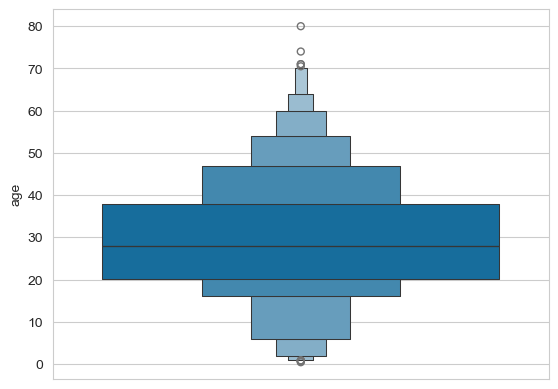

In [40]:
sns.boxenplot(data=df2['age'])

A **violin plot** combines a boxplot with a kernel density estimate:

<Axes: xlabel='age', ylabel='pclass'>

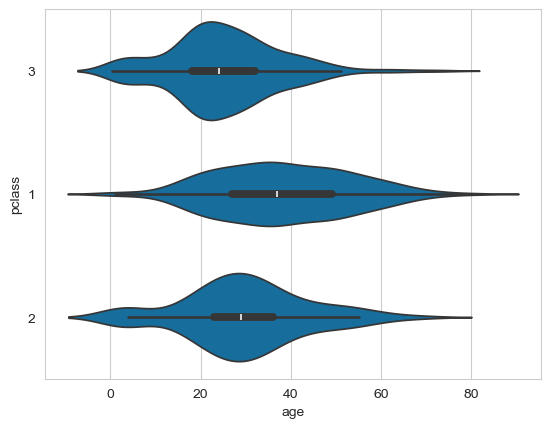

In [41]:
sns.violinplot(data=df2, x="age", y="pclass")

<Axes: xlabel='age', ylabel='pclass'>

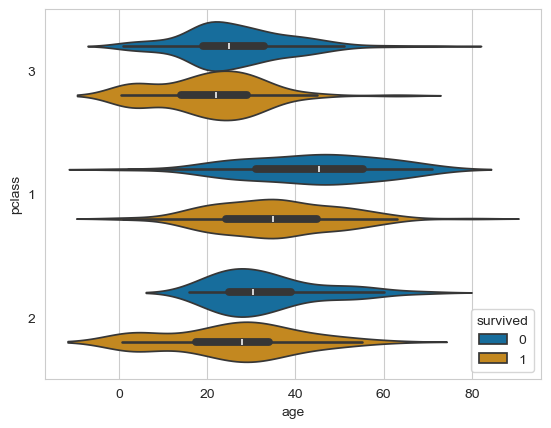

In [42]:
sns.violinplot(data=df2, x="age", y="pclass", hue="survived")

The **stripplot** and **swarmplot** display individual data points:

<Axes: xlabel='total_bill', ylabel='day'>

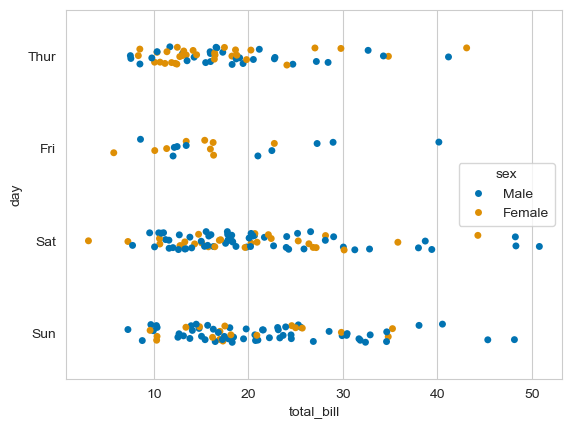

In [43]:
sns.stripplot(data=df4, x="total_bill", y="day", hue="sex")

<Axes: xlabel='total_bill', ylabel='day'>

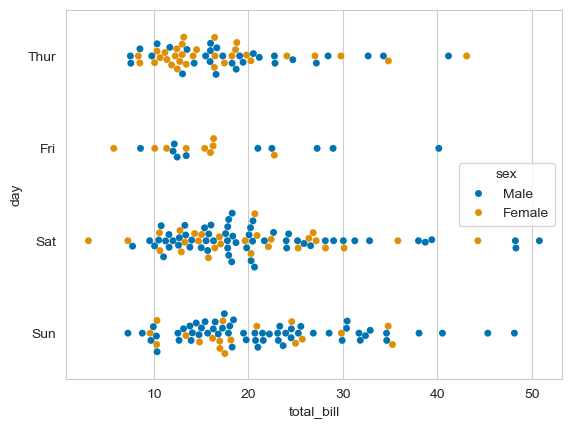

In [44]:
sns.swarmplot(data=df4, x="total_bill", y="day", hue="sex")

### Matrix plots <a id="Matrix_plots"></a>

A **heatmap** represents values through color encoding and is often used to display *correlation* matrices:

<Axes: >

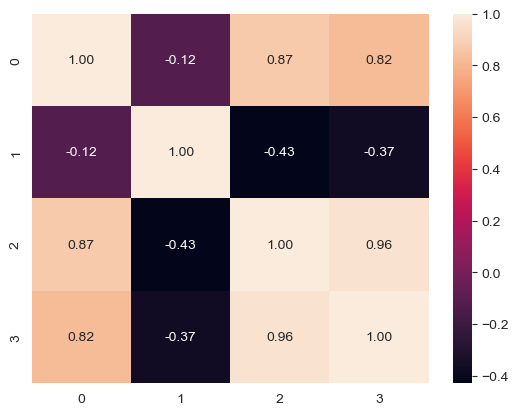

In [45]:
import numpy as np

X = df1.iloc[:,:4].values
cm = np.corrcoef(X.T)   # From NumPy

sns.heatmap(cm, annot=True, fmt=".2f")

The **clustermap** extends the heatmap by applying hierarchical clustering:

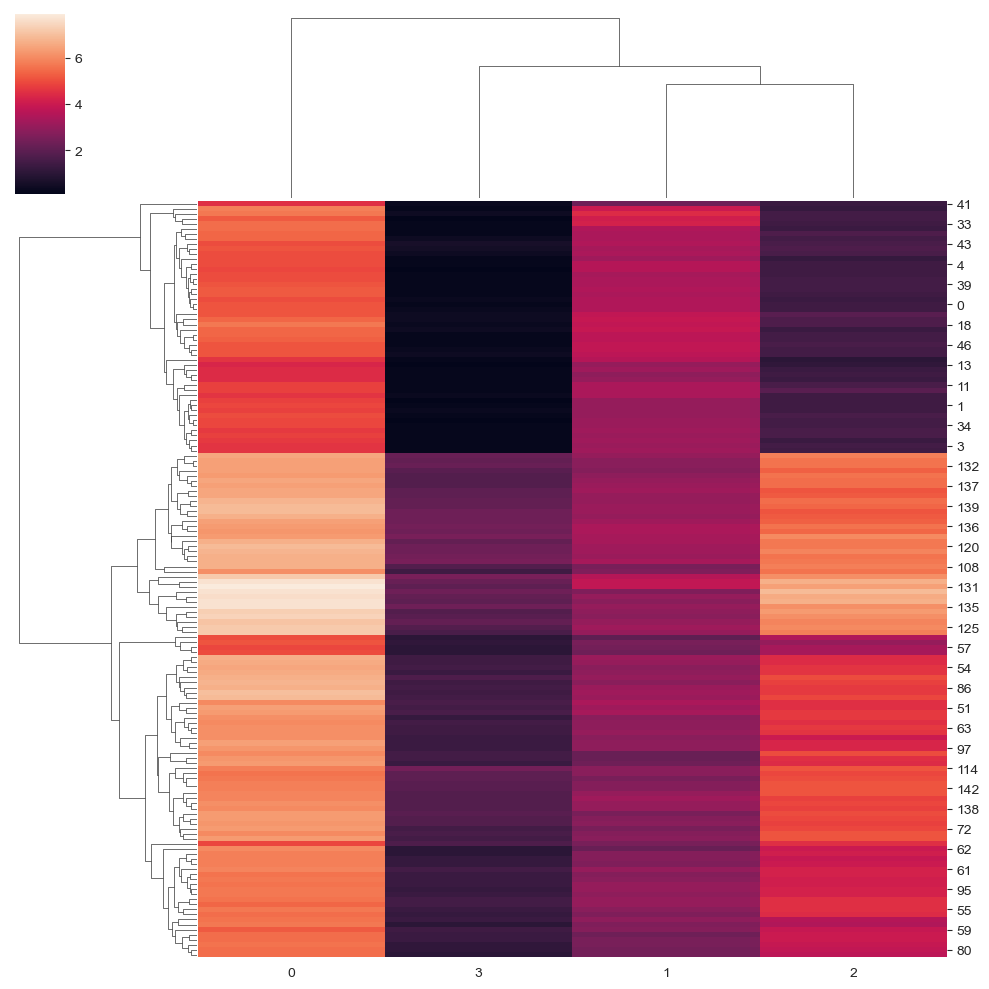

In [46]:
sns.clustermap(X)

### Multidimensional data plots <a id="Multidimensional_plots"></a>

The **RadViz** plot projects *multidimensional* data onto a two-dimensional space, by showing each data sample on a circle:

C:\Users\miche\AppData\Local\Temp\ipykernel_29652\1401098600.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['pclass'] = X.pclass.astype(int)


<Axes: >

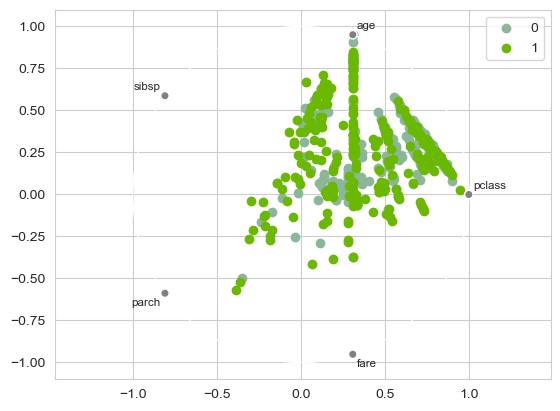

In [47]:
from pandas.plotting import radviz

#radviz(df2, "survived")

X = df2.copy()
X = df2[["survived", "pclass", "age", "sibsp", "parch", "fare"]]
X['pclass'] = X.pclass.astype(int)

radviz(X, "survived")

The **parallel coordinates plot** represents each observation as a line across parallel axes:

<Axes: >

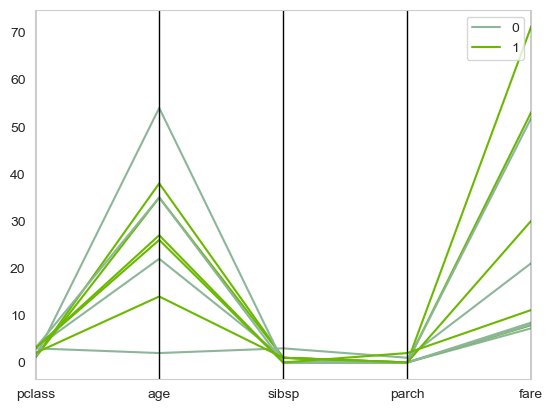

In [48]:
from pandas.plotting import parallel_coordinates

parallel_coordinates(X[:10], "survived")